In [1]:
#libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost available ✓")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed — using Random Forest as primary model.")

PALETTE = {
    "low":      "#1D9E75",
    "moderate": "#EF9F27",
    "high":     "#D85A30",
    "primary":  "#534AB7",
    "neutral":  "#888780",
}
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        110,
})

XGBoost available ✓


In [2]:
def generate_telematics_data(n_drivers: int = 2000, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)


    latent_risk = rng.beta(a=1.5, b=4.0, size=n_drivers)

    speeding_pct      = np.clip(latent_risk * 0.35 + rng.normal(0, 0.06, n_drivers), 0, 1)
    harsh_braking     = np.clip(latent_risk * 12   + rng.exponential(1.5, n_drivers), 0, 20)
    harsh_accel       = np.clip(latent_risk * 10   + rng.exponential(1.2, n_drivers), 0, 18)
    cornering         = np.clip(latent_risk * 8    + rng.exponential(1.0, n_drivers), 0, 15)
    night_driving_pct = np.clip(latent_risk * 0.30 + rng.beta(1.2, 6.0, n_drivers) * 0.20, 0, 1)
    rush_hour_pct     = np.clip(rng.beta(2.0, 3.0, n_drivers) + latent_risk * 0.10, 0, 1)
    avg_trip_km       = np.clip(rng.lognormal(mean=2.8, sigma=0.6, size=n_drivers), 2, 120)
    monthly_km        = np.clip(avg_trip_km * rng.poisson(lam=22, size=n_drivers), 50, 5000)
    phone_use         = np.clip(latent_risk * 3.5  + rng.exponential(0.5, n_drivers), 0, 8)
    max_speed         = np.clip(80 + latent_risk * 80 + rng.normal(0, 12, n_drivers), 60, 220)
    age               = np.clip(rng.normal(38, 12, n_drivers), 18, 75).astype(int)
    vehicle_age       = np.clip(rng.exponential(5, n_drivers), 0, 25).astype(int)

    # Target: top 25% of latent risk = high risk
    threshold_high = np.percentile(latent_risk, 75)
    is_high_risk   = (latent_risk >= threshold_high).astype(int)

    return pd.DataFrame({
        "driver_id":              [f"DRV-{i:04d}" for i in range(n_drivers)],
        "age":                    age,
        "vehicle_age_yrs":        vehicle_age,
        "speeding_pct":           speeding_pct.round(4),
        "harsh_braking_per100km": harsh_braking.round(2),
        "harsh_accel_per100km":   harsh_accel.round(2),
        "cornering_per100km":     cornering.round(2),
        "night_driving_pct":      night_driving_pct.round(4),
        "rush_hour_pct":          rush_hour_pct.round(4),
        "avg_trip_km":            avg_trip_km.round(1),
        "monthly_km":             monthly_km.round(0).astype(int),
        "phone_use_per_trip":     phone_use.round(2),
        "max_speed_kmh":          max_speed.round(1),
        "latent_risk":            latent_risk.round(4),
        "is_high_risk":           is_high_risk,
    })

df = generate_telematics_data(n_drivers=2000)
print(f"Dataset shape : {df.shape}")
print(f"High-risk drivers: {df['is_high_risk'].sum():,} ({df['is_high_risk'].mean():.1%})")
df.head(5)


Dataset shape : (2000, 15)
High-risk drivers: 500 (25.0%)


,driver_id,age,vehicle_age_yrs,speeding_pct,harsh_braking_per100km,harsh_accel_per100km,cornering_per100km,night_driving_pct,rush_hour_pct,avg_trip_km,monthly_km,phone_use_per_trip,max_speed_kmh,latent_risk,is_high_risk
0,DRV-0000,40,25,0.0860,5.02,2.44,2.96,0.1218,0.8212,24.2,508,1.39,106.8,0.2238,0
1,DRV-0001,35,11,0.1381,3.25,3.06,2.57,0.1554,0.2663,13.5,256,1.37,112.2,0.2650,0
2,DRV-0002,42,0,0.0115,5.45,6.00,4.02,0.1931,0.3055,7.7,124,1.43,101.1,0.3872,0
3,DRV-0003,18,0,0.0679,6.62,5.36,3.13,0.1401,0.3299,28.2,734,2.04,108.0,0.2834,0
4,DRV-0004,50,0,0.1685,6.34,4.77,5.06,0.1680,0.1901,31.9,446,1.99,137.7,0.4189,1


## Exploratory Data Analysis


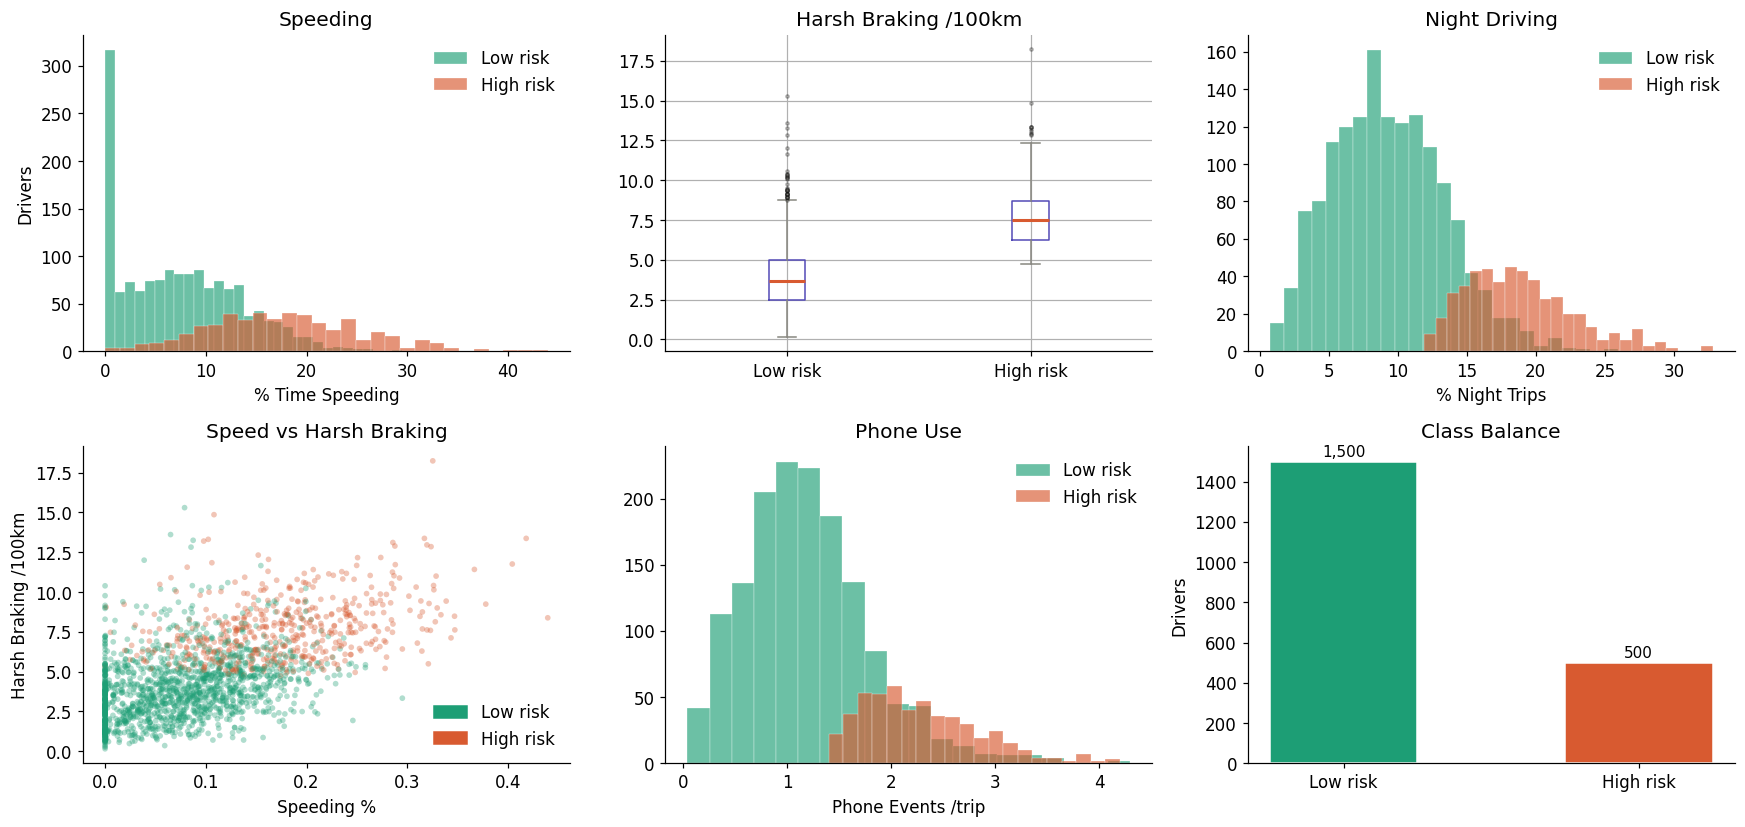

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Telematics Features by Risk Class", fontsize=14, y=1.01)
risk_colors = [PALETTE["low"] if r == 0 else PALETTE["high"] for r in df["is_high_risk"]]

# Speeding
ax = axes[0, 0]
for label, grp in df.groupby("is_high_risk"):
    col  = PALETTE["high"] if label else PALETTE["low"]
    name = "High risk" if label else "Low risk"
    ax.hist(grp["speeding_pct"] * 100, bins=30, alpha=0.65, color=col,
            label=name, edgecolor="white", linewidth=0.3)
ax.set_xlabel("% Time Speeding"); ax.set_ylabel("Drivers"); ax.set_title("Speeding")
ax.legend(frameon=False)

#  Harsh braking
ax = axes[0, 1]
df.boxplot(column="harsh_braking_per100km", by="is_high_risk", ax=ax,
           boxprops=dict(color=PALETTE["primary"]),
           medianprops=dict(color=PALETTE["high"], linewidth=2),
           whiskerprops=dict(color=PALETTE["neutral"]),
           capprops=dict(color=PALETTE["neutral"]),
           flierprops=dict(marker="o", markersize=2, alpha=0.3,
                           markerfacecolor=PALETTE["neutral"]))
ax.set_xticklabels(["Low risk", "High risk"]); ax.set_xlabel("")
ax.set_title("Harsh Braking /100km"); plt.sca(ax); plt.title("Harsh Braking /100km")
fig.texts = [t for t in fig.texts if "Boxplot" not in t.get_text()]

#  Night driving
ax = axes[0, 2]
for label, grp in df.groupby("is_high_risk"):
    col  = PALETTE["high"] if label else PALETTE["low"]
    name = "High risk" if label else "Low risk"
    ax.hist(grp["night_driving_pct"] * 100, bins=25, alpha=0.65, color=col,
            label=name, edgecolor="white", linewidth=0.3)
ax.set_xlabel("% Night Trips"); ax.set_title("Night Driving"); ax.legend(frameon=False)

#  Speed vs Harsh Events scatter
ax = axes[1, 0]
ax.scatter(df["speeding_pct"], df["harsh_braking_per100km"],
           c=risk_colors, alpha=0.35, s=14, linewidths=0)
ax.set_xlabel("Speeding %"); ax.set_ylabel("Harsh Braking /100km")
ax.set_title("Speed vs Harsh Braking")
low_p  = mpatches.Patch(color=PALETTE["low"],  label="Low risk")
high_p = mpatches.Patch(color=PALETTE["high"], label="High risk")
ax.legend(handles=[low_p, high_p], frameon=False)

#  Phone use
ax = axes[1, 1]
for label, grp in df.groupby("is_high_risk"):
    col  = PALETTE["high"] if label else PALETTE["low"]
    name = "High risk" if label else "Low risk"
    ax.hist(grp["phone_use_per_trip"], bins=20, alpha=0.65, color=col,
            label=name, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Phone Events /trip"); ax.set_title("Phone Use"); ax.legend(frameon=False)

#  Class balance
ax = axes[1, 2]
counts = df["is_high_risk"].value_counts().sort_index()
bars = ax.bar(["Low risk", "High risk"], counts.values,
              color=[PALETTE["low"], PALETTE["high"]], width=0.5, edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{val:,}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Drivers"); ax.set_title("Class Balance")

plt.tight_layout()
plt.savefig("01_eda_overview.png", bbox_inches="tight", dpi=110)
plt.show()


## Feature Engineering

In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Composite harsh event index (weighted sum, normalised 0-1)
    df["harsh_event_index"] = (
        (df["harsh_braking_per100km"] / 20 * 0.4) +
        (df["harsh_accel_per100km"]   / 18 * 0.3) +
        (df["cornering_per100km"]     / 15 * 0.3)
    ).clip(0, 1).round(4)

    # Risk time: exposure during high-risk time windows
    df["risk_time_pct"] = (
        df["night_driving_pct"] * 0.6 + df["rush_hour_pct"] * 0.4
    ).clip(0, 1).round(4)

    # Speed risk: combines speeding frequency + absolute max speed
    df["speed_risk_index"] = (
        df["speeding_pct"] * 0.55 +
        (df["max_speed_kmh"].clip(60, 180) - 60) / 120 * 0.45
    ).clip(0, 1).round(4)

    # Distraction score
    df["distraction_score"] = (df["phone_use_per_trip"] / 8).clip(0, 1).round(4)

    # Mileage exposure band (0=low, 3=very high)
    df["mileage_band"] = pd.cut(df["monthly_km"],
        bins=[0, 500, 1500, 3000, 5001], labels=[0, 1, 2, 3]).astype(int)

    # U-shaped age risk (young < 25 or senior > 65)
    df["age_risk_flag"] = ((df["age"] < 25) | (df["age"] > 65)).astype(int)

    return df

df = engineer_features(df)

FEATURE_COLS = [
    "speeding_pct", "harsh_braking_per100km", "harsh_accel_per100km",
    "cornering_per100km", "night_driving_pct", "rush_hour_pct",
    "avg_trip_km", "monthly_km", "phone_use_per_trip", "max_speed_kmh",
    "age", "vehicle_age_yrs",
    "harsh_event_index", "risk_time_pct", "speed_risk_index",
    "distraction_score", "mileage_band", "age_risk_flag",
]

print(f"Total features: {len(FEATURE_COLS)}")
print("\nEngineered feature sample:")
df[["driver_id", "harsh_event_index", "speed_risk_index",
    "distraction_score", "risk_time_pct"]].head(5)


Total features: 18

Engineered feature sample:


,driver_id,harsh_event_index,speed_risk_index,distraction_score,risk_time_pct
0,DRV-0000,0.2003,0.2228,0.1737,0.4016
1,DRV-0001,0.1674,0.2717,0.1713,0.1998
2,DRV-0002,0.2894,0.1604,0.1788,0.2381
3,DRV-0003,0.2843,0.2173,0.2550,0.2160
4,DRV-0004,0.3075,0.3840,0.2488,0.1768


### Feature Correlation Heatmap

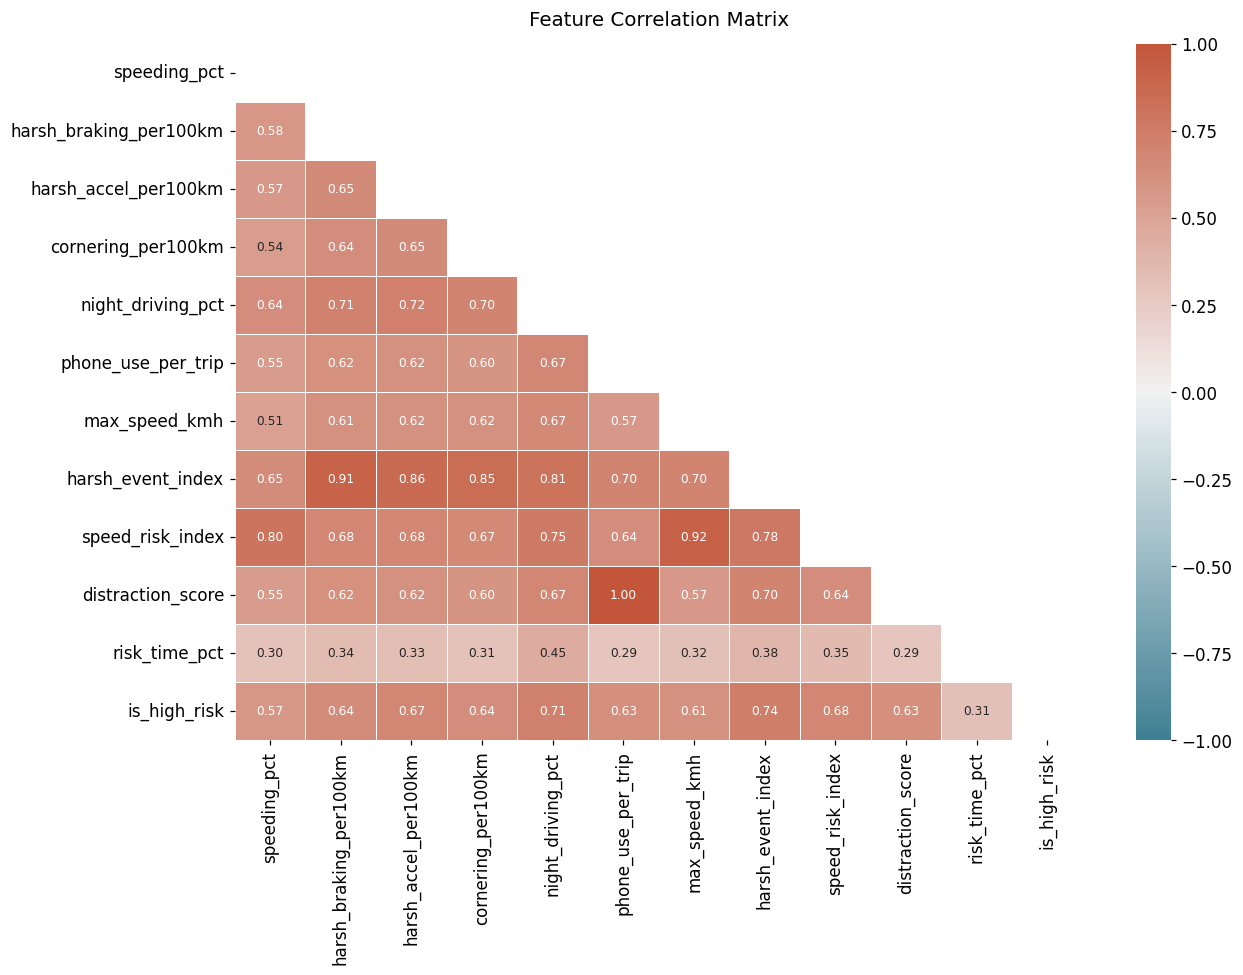

High correlation with is_high_risk:
harsh_event_index         0.740295
night_driving_pct         0.714587
speed_risk_index          0.682106
harsh_accel_per100km      0.672555
harsh_braking_per100km    0.643000
cornering_per100km        0.635163
distraction_score         0.625258
phone_use_per_trip        0.625244
max_speed_kmh             0.612004
speeding_pct              0.574961
risk_time_pct             0.312801


In [5]:
fig, ax = plt.subplots(figsize=(12, 9))
key_features = [
    "speeding_pct", "harsh_braking_per100km", "harsh_accel_per100km",
    "cornering_per100km", "night_driving_pct", "phone_use_per_trip",
    "max_speed_kmh", "harsh_event_index", "speed_risk_index",
    "distraction_score", "risk_time_pct", "is_high_risk",
]
corr = df[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", linewidths=0.4,
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight", dpi=110)
plt.show()
print("High correlation with is_high_risk:")
print(corr["is_high_risk"].drop("is_high_risk").sort_values(ascending=False).to_string())


## Model Training



In [6]:
X = df[FEATURE_COLS].values
y = df["is_high_risk"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train set : {len(X_train):,} drivers  ({y_train.mean():.1%} high risk)")
print(f"Test set  : {len(X_test):,}  drivers  ({y_test.mean():.1%} high risk)")


Train set : 1,600 drivers  (25.0% high risk)
Test set  : 400  drivers  (25.0% high risk)


In [7]:
results = {}

# ── Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)
results["Random Forest"] = {"model": rf, "prob": rf_prob, "auc": rf_auc}
print(f"Random Forest   — AUC: {rf_auc:.4f}")

# ── Logistic Regression
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(C=1.0, class_weight="balanced",
                               max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_prob = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_prob)
results["Logistic Regression"] = {"model": lr_pipe, "prob": lr_prob, "auc": lr_auc}
print(f"Logistic Reg.   — AUC: {lr_auc:.4f}")

# ── XGBoost (optional)
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        use_label_encoder=False, eval_metric="auc",
        random_state=42, verbosity=0
    )
    xgb.fit(X_train, y_train)
    xgb_prob = xgb.predict_proba(X_test)[:, 1]
    xgb_auc  = roc_auc_score(y_test, xgb_prob)
    results["XGBoost"] = {"model": xgb, "prob": xgb_prob, "auc": xgb_auc}
    print(f"XGBoost         — AUC: {xgb_auc:.4f}")

best_name = max(results, key=lambda k: results[k]["auc"])
print(f"\nBest model: {best_name} (AUC = {results[best_name]['auc']:.4f})")


Random Forest   — AUC: 0.9979
Logistic Reg.   — AUC: 0.9944
XGBoost         — AUC: 0.9973

Best model: Random Forest (AUC = 0.9979)


## Model Evaluation

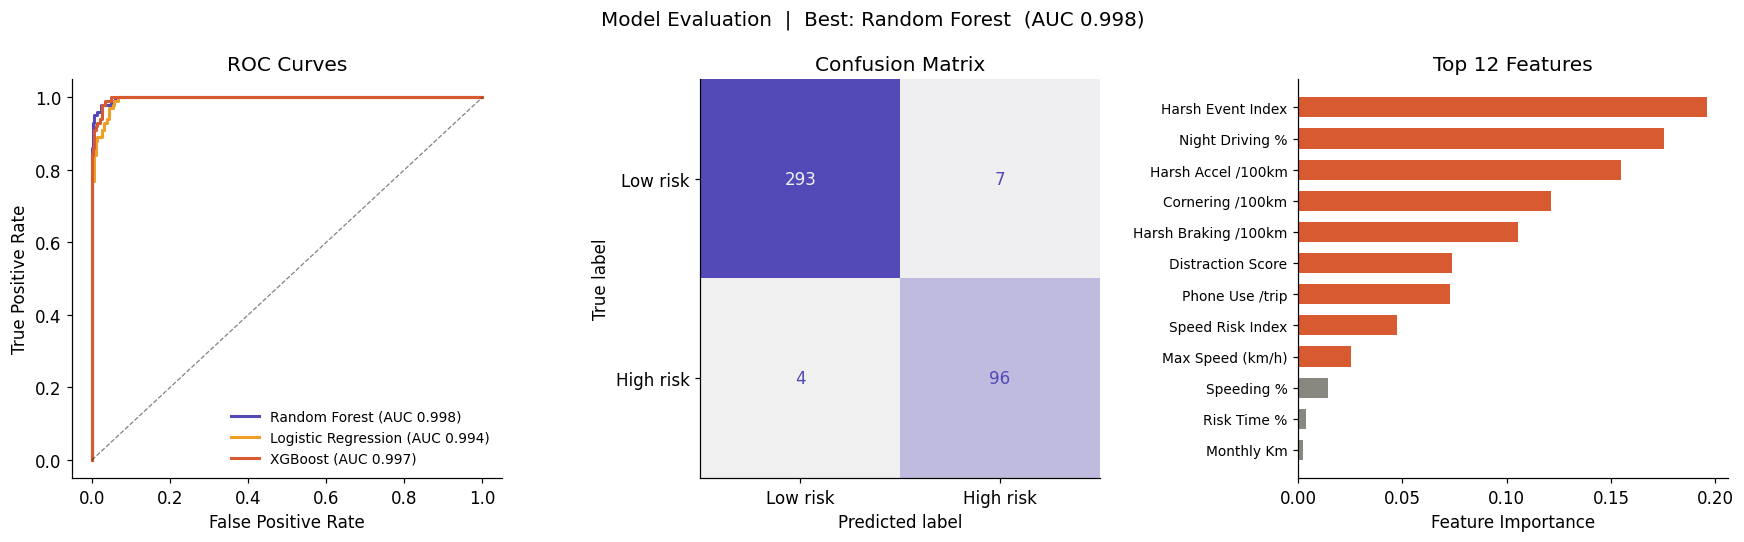


Classification Report — Random Forest:
              precision    recall  f1-score   support

    Low risk       0.99      0.98      0.98       300
   High risk       0.93      0.96      0.95       100

    accuracy                           0.97       400
   macro avg       0.96      0.97      0.96       400
weighted avg       0.97      0.97      0.97       400



In [8]:
best      = results[best_name]
best_model= best["model"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Model Evaluation  |  Best: {best_name}  (AUC {best['auc']:.3f})", fontsize=13)

# ROC curves
ax = axes[0]
colors_ = [PALETTE["primary"], PALETTE["moderate"], PALETTE["high"]]
for (name, res), col in zip(results.items(), colors_):
    fpr, tpr, _ = roc_curve(y_test, res["prob"])
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC {res['auc']:.3f})")
ax.plot([0,1],[0,1],"k--", lw=0.8, alpha=0.5)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves"); ax.legend(fontsize=9, frameon=False)

# Confusion matrix
ax = axes[1]
pred_labels = (best["prob"] >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low risk", "High risk"])
disp.plot(ax=ax, colorbar=False,
          cmap=sns.light_palette(PALETTE["primary"], as_cmap=True))
ax.set_title(f"Confusion Matrix")

# Feature importance
ax = axes[2]
importances = best_model.feature_importances_
FEATURE_LABELS = {
    "speeding_pct": "Speeding %", "harsh_braking_per100km": "Harsh Braking /100km",
    "harsh_accel_per100km": "Harsh Accel /100km", "cornering_per100km": "Cornering /100km",
    "night_driving_pct": "Night Driving %", "rush_hour_pct": "Rush Hour %",
    "avg_trip_km": "Avg Trip Distance", "monthly_km": "Monthly Km",
    "phone_use_per_trip": "Phone Use /trip", "max_speed_kmh": "Max Speed (km/h)",
    "age": "Driver Age", "vehicle_age_yrs": "Vehicle Age",
    "harsh_event_index": "Harsh Event Index", "risk_time_pct": "Risk Time %",
    "speed_risk_index": "Speed Risk Index", "distraction_score": "Distraction Score",
    "mileage_band": "Mileage Band", "age_risk_flag": "Age Risk Flag",
}
idx = np.argsort(importances)[-12:]
labels = [FEATURE_LABELS.get(FEATURE_COLS[i], FEATURE_COLS[i]) for i in idx]
bar_cols = [PALETTE["high"] if importances[i] > np.median(importances)
            else PALETTE["neutral"] for i in idx]
ax.barh(range(len(idx)), importances[idx], color=bar_cols, height=0.65)
ax.set_yticks(range(len(idx))); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Feature Importance"); ax.set_title("Top 12 Features")

plt.tight_layout()
plt.savefig("02_model_evaluation.png", bbox_inches="tight", dpi=110)
plt.show()

# Classification report
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, pred_labels, target_names=["Low risk", "High risk"]))


## Risk Score Generation

In [9]:
# Score all 2,000 drivers
all_probs = best_model.predict_proba(X)[:, 1]
df["risk_score"] = (all_probs * 100).round(1)
df["risk_tier"]  = pd.cut(df["risk_score"],
                            bins=[-1, 40, 70, 101],
                            labels=["Low", "Moderate", "High"])

print("Risk tier breakdown:")
tier_summary = df.groupby("risk_tier", observed=True)["risk_score"].agg(
    Count="count", Mean="mean", Median="median", Min="min", Max="max"
).round(1)
print(tier_summary.to_string())

print(f"\nOverall  — Mean: {df['risk_score'].mean():.1f}  |  "
      f"Median: {df['risk_score'].median():.1f}  |  "
      f"Std: {df['risk_score'].std():.1f}")


Risk tier breakdown:
           Count  Mean  Median   Min    Max
risk_tier                                  
Low         1462   2.6     0.1   0.0   39.1
Moderate      56  56.5    55.8  41.6   69.2
High         482  96.0    98.9  70.4  100.0

Overall  — Mean: 26.7  |  Median: 0.8  |  Std: 40.6


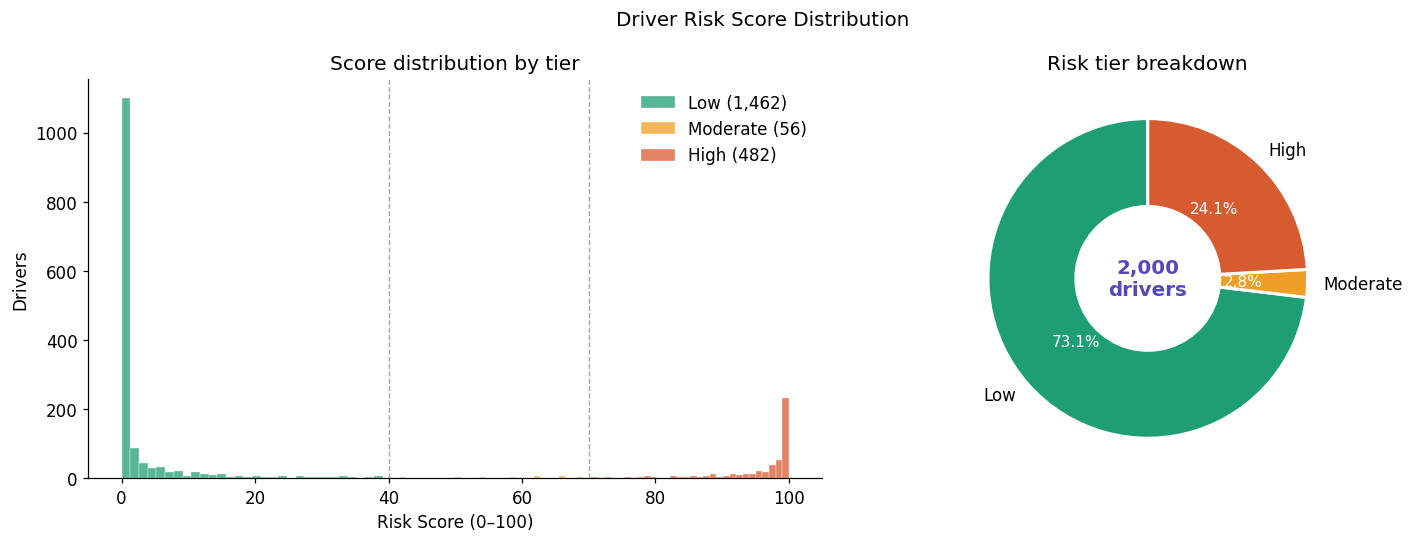

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Driver Risk Score Distribution", fontsize=13)
tier_colors = {"Low": PALETTE["low"], "Moderate": PALETTE["moderate"], "High": PALETTE["high"]}

# Histogram
ax = axes[0]
for tier in ["Low", "Moderate", "High"]:
    sub = df[df["risk_tier"] == tier]
    ax.hist(sub["risk_score"], bins=30, alpha=0.75, color=tier_colors[tier],
            label=f"{tier} ({len(sub):,})", edgecolor="white", linewidth=0.3)
ax.axvline(40, color="gray", linestyle="--", lw=0.9, alpha=0.7)
ax.axvline(70, color="gray", linestyle="--", lw=0.9, alpha=0.7)
ax.set_xlabel("Risk Score (0–100)"); ax.set_ylabel("Drivers")
ax.set_title("Score distribution by tier"); ax.legend(frameon=False)

# Donut
ax = axes[1]
tier_counts = df["risk_tier"].value_counts().reindex(["Low", "Moderate", "High"])
wedge_colors = [tier_colors[t] for t in tier_counts.index]
wedges, texts, autotexts = ax.pie(
    tier_counts.values, labels=tier_counts.index, colors=wedge_colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
for at in autotexts:
    at.set_fontsize(10); at.set_color("white")
ax.text(0, 0, f"{len(df):,}\ndrivers", ha="center", va="center",
        fontsize=13, fontweight="bold", color=PALETTE["primary"])
ax.set_title("Risk tier breakdown")

plt.tight_layout()
plt.savefig("03_risk_score_distribution.png", bbox_inches="tight", dpi=110)

plt.show()


## Driver Profile Comparison (Radar Chart)

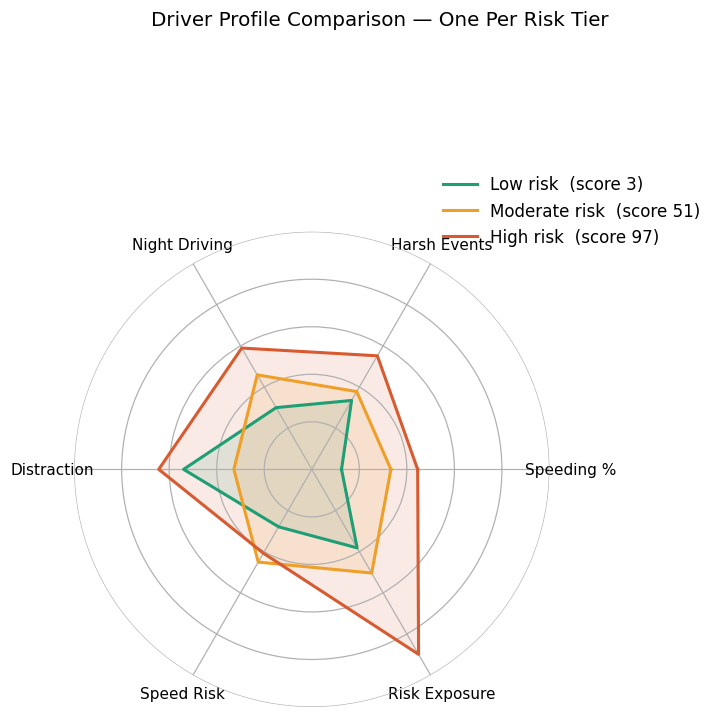

In [11]:
radar_features = [
    "speeding_pct", "harsh_event_index", "night_driving_pct",
    "distraction_score", "speed_risk_index", "risk_time_pct",
]
radar_labels = ["Speeding %", "Harsh Events", "Night Driving",
                "Distraction", "Speed Risk", "Risk Exposure"]

samples = {
    tier: df[df["risk_tier"] == tier].sample(1, random_state=99).iloc[0]
    for tier in ["Low", "Moderate", "High"]
}

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
fig.suptitle("Driver Profile Comparison — One Per Risk Tier", fontsize=13, y=1.02)

for (tier, row), col in zip(samples.items(),
                              [PALETTE["low"], PALETTE["moderate"], PALETTE["high"]]):
    vals = [min(row[f] / df[f].max(), 1.0) for f in radar_features]
    vals += vals[:1]
    ax.plot(angles, vals, color=col, linewidth=2,
            label=f"{tier} risk  (score {row['risk_score']:.0f})")
    ax.fill(angles, vals, color=col, alpha=0.12)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1); ax.set_yticklabels([]); ax.spines["polar"].set_visible(False)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), frameon=False)
plt.tight_layout()
plt.savefig("04_driver_profiles_radar.png", bbox_inches="tight", dpi=110)
plt.show()
